# School Alcohol Consumption Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
math_df = pd.read_csv('/content/student-mat.csv')
math_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
por_df = pd.read_csv('/content/student-por.csv')
por_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
math_df["subject"] = "math"
por_df["subject"] = "portuguese"

In [ ]:
# Concatenate the two datasets
combined_df = pd.concat([math_df, por_df], ignore_index=True)
combined_df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math


In [ ]:
# Preview the combined dataset
print(combined_df.shape)

(1044, 34)


In [ ]:
combined_df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
1039,MS,F,19,R,GT3,T,2,3,services,other,...,4,2,1,2,5,4,10,11,10,portuguese
1040,MS,F,18,U,LE3,T,3,1,teacher,services,...,3,4,1,1,1,4,15,15,16,portuguese
1041,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,5,6,11,12,9,portuguese
1042,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,6,10,10,10,portuguese
1043,MS,M,18,R,LE3,T,3,2,services,other,...,4,1,3,4,5,4,10,11,11,portuguese


In [ ]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [ ]:
combined_df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
combined_df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [ ]:
combined_df.duplicated().sum()

np.int64(0)

In [ ]:
import warnings; warnings.filterwarnings('ignore')

---
# **School Authorities**
---

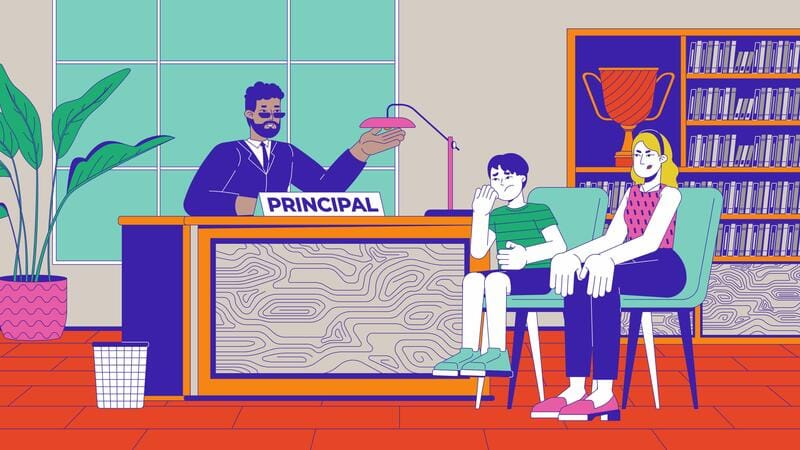

#**Q1. How does receiving academic support (e.g., schoolsup, famsup) or participating in extracurriculars influence weekday alcohol use and academic performance?**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Copy combined dataset
df = combined_df.copy()

# Ensure 'yes'/'no' are treated as categories
for col in ['schoolsup', 'famsup', 'activities']:
    df[col] = df[col].astype('category')

sns.set(style="whitegrid")
light_palette = sns.color_palette("pastel")

# -----------------------------
# 1. Average Academic Performance by Support Type
# -----------------------------
support_types = ['schoolsup', 'famsup', 'activities']
plot_data = []

for support in support_types:
    support_avg = df.groupby(support)['avg_grade'].mean().reset_index()
    support_avg['Support_Type'] = support
    support_avg.rename(columns={support: 'Support_Received', 'avg_grade': 'Average_Grade'}, inplace=True)
    plot_data.append(support_avg)

grade_plot_df = pd.concat(plot_data)

plt.figure(figsize=(6, 4))
ax1 = sns.barplot(
    data=grade_plot_df,
    x='Support_Type',
    y='Average_Grade',
    hue='Support_Received',
    ci='sd',
    palette=light_palette
)
ax1.set_title('Avg Academic Performance by Support')
ax1.set_ylabel('Avg Grade')
ax1.set_xlabel('Support Type')
ax1.legend(title='Support Received', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

# -----------------------------
# 2. Average Weekday Alcohol Use by Support Type
# -----------------------------
alc_plot_data = []

for support in support_types:
    support_alc = df.groupby(support)['Dalc'].mean().reset_index()
    support_alc['Support_Type'] = support
    support_alc.rename(columns={support: 'Support_Received', 'Dalc': 'Average_Dalc'}, inplace=True)
    alc_plot_data.append(support_alc)

alc_plot_df = pd.concat(alc_plot_data)

plt.figure(figsize=(6, 4))
ax2 = sns.barplot(
    data=alc_plot_df,
    x='Support_Type',
    y='Average_Dalc',
    hue='Support_Received',
    ci='sd',
    palette=light_palette
)
ax2.set_title('Avg Weekday Alcohol Use by Support')
ax2.set_ylabel('Alcohol Use (Dalc)')
ax2.set_xlabel('Support Type')
ax2.legend(title='Support Received', loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()


KeyError: 'Column not found: avg_grade'

Students with support systems — like school help, family involvement, or activities — tend to drink slightly less and perform slightly better academically, especially those involved in extracurriculars.

# **Q2.How do lifestyle factors like students’ health, study time, and commute (travel time) relate to their alcohol consumption habits?**


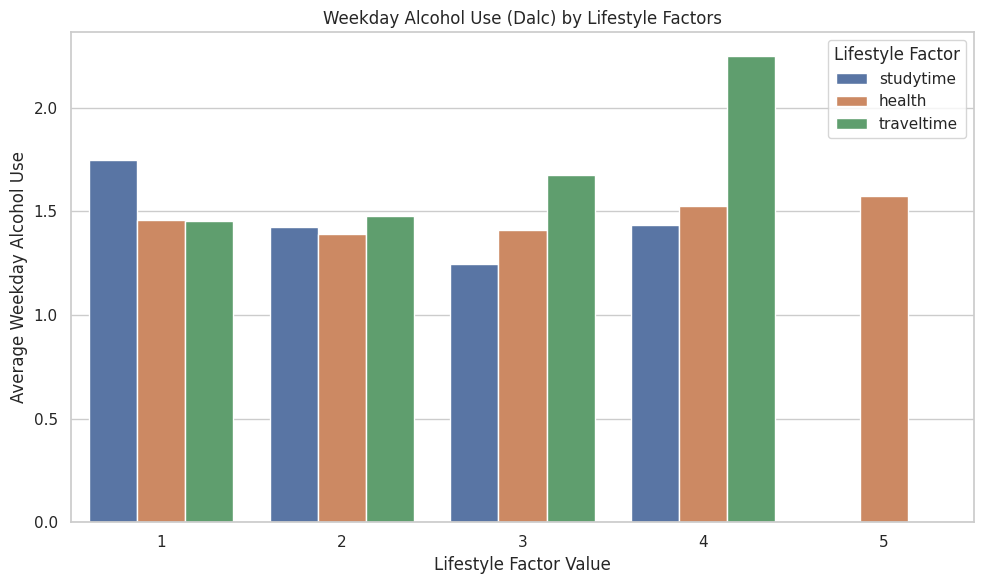

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Select only the relevant columns
columns_of_interest = ['Dalc', 'Walc', 'studytime', 'health', 'traveltime']
df_filtered = combined_df[columns_of_interest]

# Melt the data to group it by lifestyle factor
df_melted = pd.melt(
    df_filtered,
    id_vars=['Dalc', 'Walc'],
    value_vars=['studytime', 'health', 'traveltime'],
    var_name='Lifestyle Factor',
    value_name='Value'
)

# Plot: Weekday Alcohol Use vs Lifestyle Factors
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Value', y='Dalc', hue='Lifestyle Factor', ci=None)
plt.title('Weekday Alcohol Use (Dalc) by Lifestyle Factors')
plt.xlabel('Lifestyle Factor Value')
plt.ylabel('Average Weekday Alcohol Use')
plt.legend(title='Lifestyle Factor')
plt.tight_layout()
plt.show()


**Insight:**  
> Students with lower study time, poor health, or longer travel time tend to report **higher weekday alcohol consumption**, suggesting lifestyle challenges may be linked to increased drinking..



#**Q3.  Is there a clear link between higher alcohol(weekday dalc or weekend walc) and lower final grades ?**

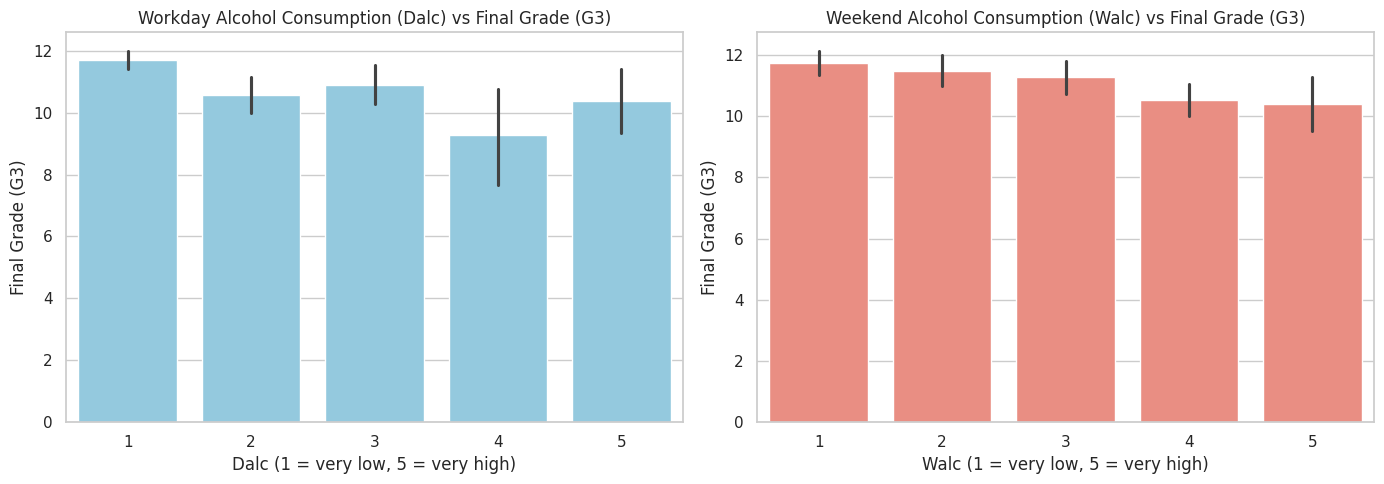

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style="whitegrid")

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # width increased for better spacing

# Plot Dalc vs G3
sns.barplot(x='Dalc', y='G3', data=combined_df, color='skyblue', ax=axes[0])
axes[0].set_title("Workday Alcohol Consumption (Dalc) vs Final Grade (G3)")
axes[0].set_xlabel("Dalc (1 = very low, 5 = very high)")
axes[0].set_ylabel("Final Grade (G3)")

# Plot Walc vs G3
sns.barplot(x='Walc', y='G3', data=combined_df, color='salmon', ax=axes[1])
axes[1].set_title("Weekend Alcohol Consumption (Walc) vs Final Grade (G3)")
axes[1].set_xlabel("Walc (1 = very low, 5 = very high)")
axes[1].set_ylabel("Final Grade (G3)")

# Adjust layout
plt.tight_layout()
plt.show()



#**Insights**

> There is a noticeable negative relationship between alcohol consumption and academic performance. Students who consume more alcohol — especially during weekdays (Dalc) — tend to have lower final grades (G3). This suggests that frequent drinking may interfere with study routines and academic focus.
Weekend alcohol consumption (Walc) also shows a downward trend in grades, but the impact appears slightly less pronounced than weekday drinking.




---
#**Family**
---


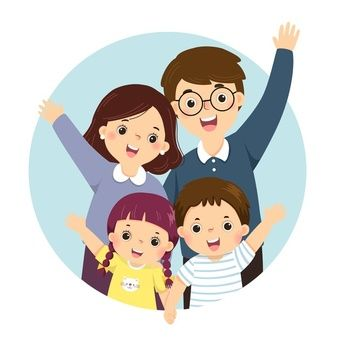

# **Q4. How do parental Education levels(Medu ,fedu) and family relationship quality(famrel) affect students alcohol use?**

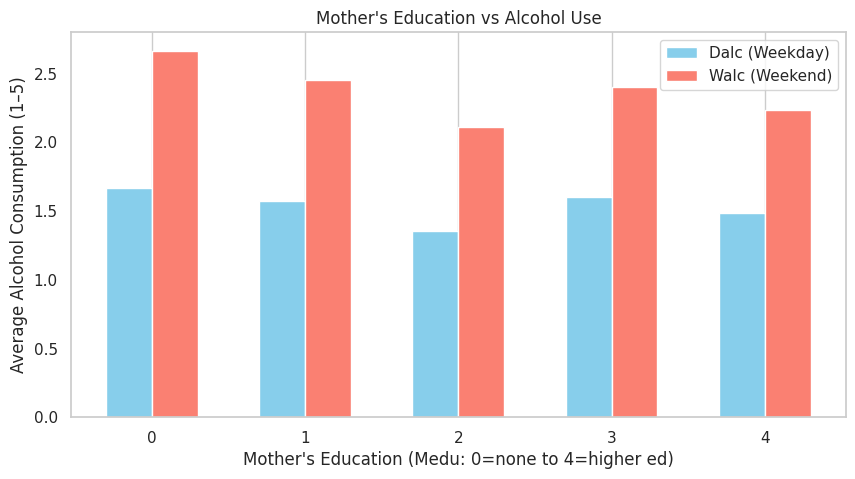

In [ ]:
import matplotlib.pyplot as plt

# Average alcohol use by Medu
medu_dalc = combined_df.groupby('Medu')['Dalc'].mean()
medu_walc = combined_df.groupby('Medu')['Walc'].mean()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(medu_dalc.index - 0.15, medu_dalc.values, width=0.3, label='Dalc (Weekday)', color='skyblue')
plt.bar(medu_walc.index + 0.15, medu_walc.values, width=0.3, label='Walc (Weekend)', color='salmon')
plt.xlabel("Mother's Education (Medu: 0=none to 4=higher ed)")
plt.ylabel("Average Alcohol Consumption (1–5)")
plt.title("Mother's Education vs Alcohol Use")
plt.legend()
plt.grid(axis='y')
plt.show()


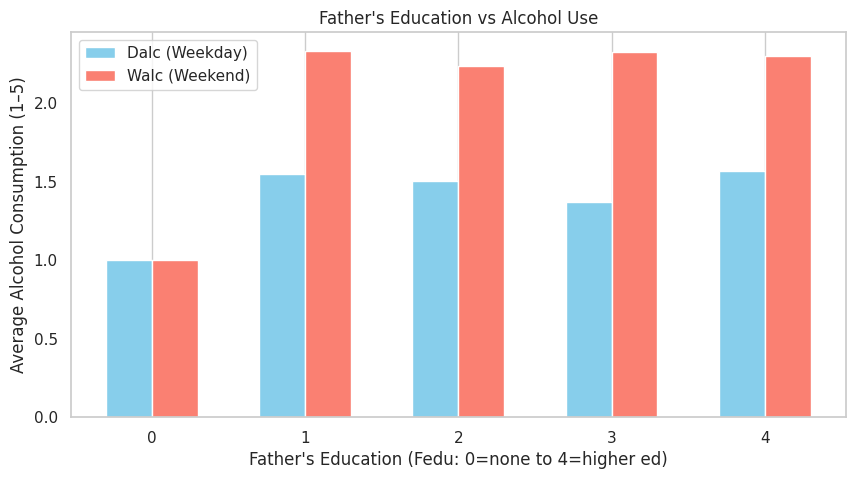

In [ ]:
# Average alcohol use by Fedu
fedu_dalc = combined_df.groupby('Fedu')['Dalc'].mean()
fedu_walc = combined_df.groupby('Fedu')['Walc'].mean()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(fedu_dalc.index - 0.15, fedu_dalc.values, width=0.3, label='Dalc (Weekday)', color='skyblue')
plt.bar(fedu_walc.index + 0.15, fedu_walc.values, width=0.3, label='Walc (Weekend)', color='salmon')
plt.xlabel("Father's Education (Fedu: 0=none to 4=higher ed)")
plt.ylabel("Average Alcohol Consumption (1–5)")
plt.title("Father's Education vs Alcohol Use")
plt.legend()
plt.grid(axis='y')
plt.show()


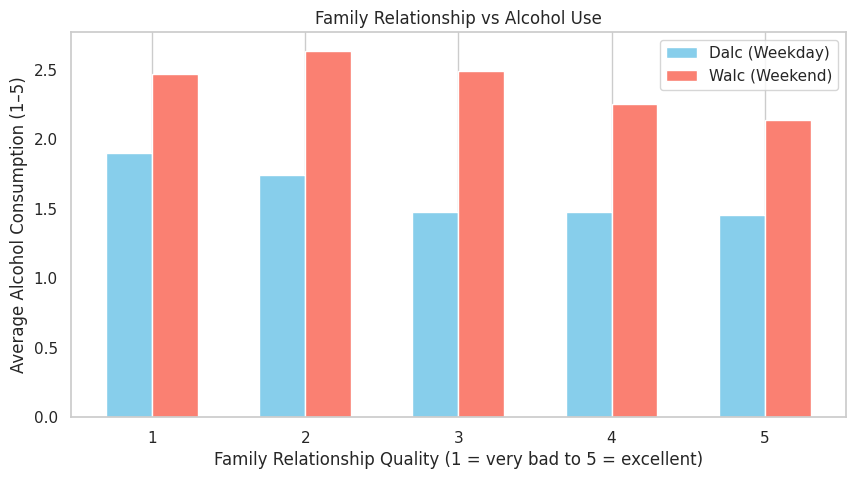

In [ ]:
# Average alcohol use by famrel
famrel_dalc = combined_df.groupby('famrel')['Dalc'].mean()
famrel_walc = combined_df.groupby('famrel')['Walc'].mean()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(famrel_dalc.index - 0.15, famrel_dalc.values, width=0.3, label='Dalc (Weekday)', color='skyblue')
plt.bar(famrel_walc.index + 0.15, famrel_walc.values, width=0.3, label='Walc (Weekend)', color='salmon')
plt.xlabel("Family Relationship Quality (1 = very bad to 5 = excellent)")
plt.ylabel("Average Alcohol Consumption (1–5)")
plt.title("Family Relationship vs Alcohol Use")
plt.legend()
plt.grid(axis='y')
plt.show()


# **Q5. Are students in urban areas drinking more due to nightlife/accessibility, and if so, how does this compare with rural students in terms of academic performance?**


# Objective:

To investigate whether students living in urban areas (address = U) consume more alcohol due to potential nightlife or easier access, and to compare their academic performance (G3, final grades) with that of students from rural areas (address = R).

This will help understand if urban students’ environment correlates with higher alcohol use and whether it impacts their grades.italicized text

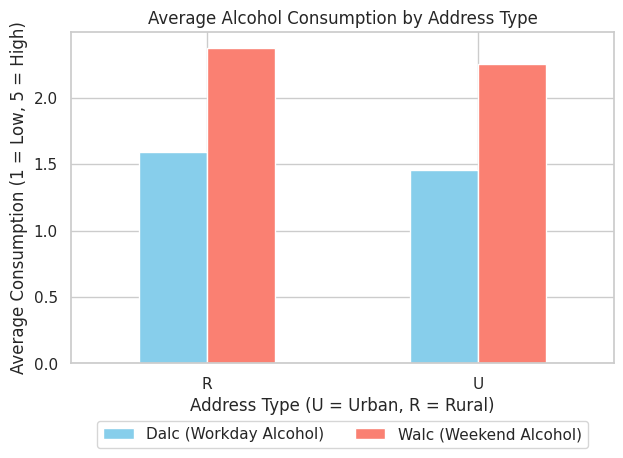

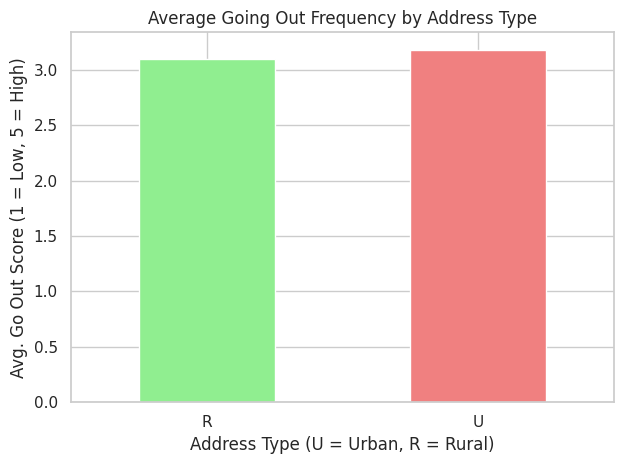

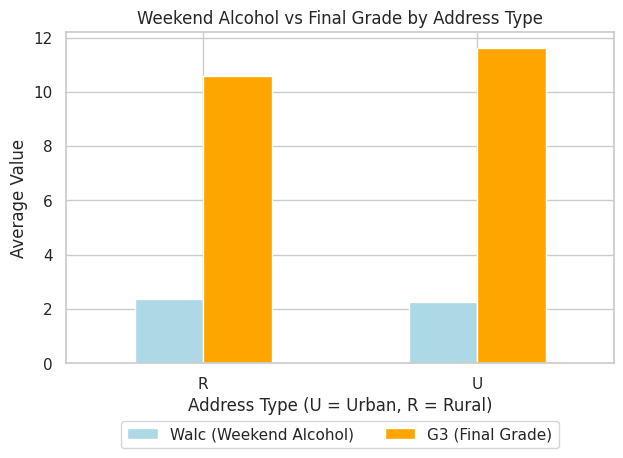

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
math_df = pd.read_csv('/content/student-mat.csv')
por_df = pd.read_csv('/content/student-por.csv')

# Add a new column to track course type
math_df['course'] = 'Math'
por_df['course'] = 'Portuguese'

# Combine both datasets
df = pd.concat([math_df, por_df], ignore_index=True)

# 1. Bar Chart: Average Alcohol Consumption (Dalc and Walc) by Address
avg_alcohol = df.groupby('address')[['Dalc', 'Walc']].mean()
ax = avg_alcohol.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Average Alcohol Consumption by Address Type")
plt.ylabel("Average Consumption (1 = Low, 5 = High)")
plt.xlabel("Address Type (U = Urban, R = Rural)")
plt.xticks(rotation=0)
plt.legend(["Dalc (Workday Alcohol)", "Walc (Weekend Alcohol)"], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()

# 2. Bar Chart: Average Going Out Frequency by Address Type
avg_goout = df.groupby('address')['goout'].mean()
ax = avg_goout.plot(kind='bar', color=['lightgreen', 'lightcoral'])
plt.title("Average Going Out Frequency by Address Type")
plt.ylabel("Avg. Go Out Score (1 = Low, 5 = High)")
plt.xlabel("Address Type (U = Urban, R = Rural)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Bar Chart: Weekend Alcohol vs Final Grade by Address Type
avg_alcohol_grades = df.groupby('address')[['Walc', 'G3']].mean()
ax = avg_alcohol_grades.plot(kind='bar', color=['lightblue', 'orange'])
plt.title("Weekend Alcohol vs Final Grade by Address Type")
plt.ylabel("Average Value")
plt.xlabel("Address Type (U = Urban, R = Rural)")
plt.xticks(rotation=0)
plt.legend(["Walc (Weekend Alcohol)", "G3 (Final Grade)"], loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
plt.show()


# Insight:

Alcohol Consumption: Rural students consume more alcohol (both workday and
weekend) compared to urban students. This could be due to fewer recreational options in rural areas.

Social Activity: Urban students go out slightly more than rural students, likely due to better access to social spots and events in cities.

Academic Performance: Urban students have better grades, possibly due to better access to educational resources and infrastructure.





----
#**Students Themselves**
----

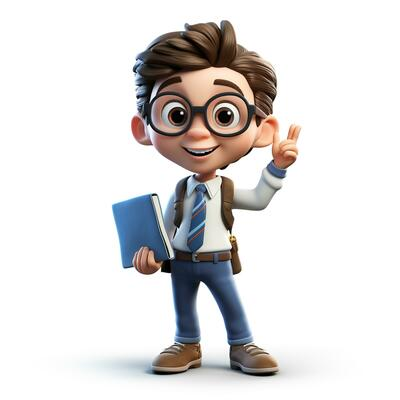

# **Q6. What is the relationship between weekend social activity (goout), romantic relationships, and alcohol consumption?**

# **Obecjtive:**

To explore how weekend social activity (goout) and romantic relationships (romantic) relate to alcohol consumption, both on weekdays (Dalc) and weekends (Walc).

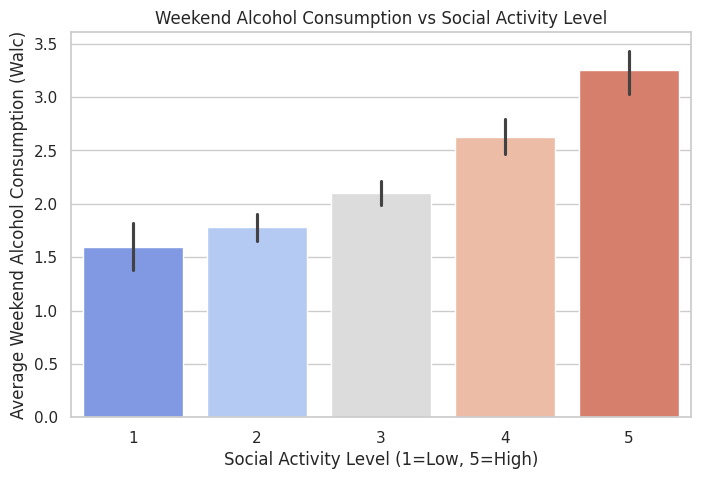

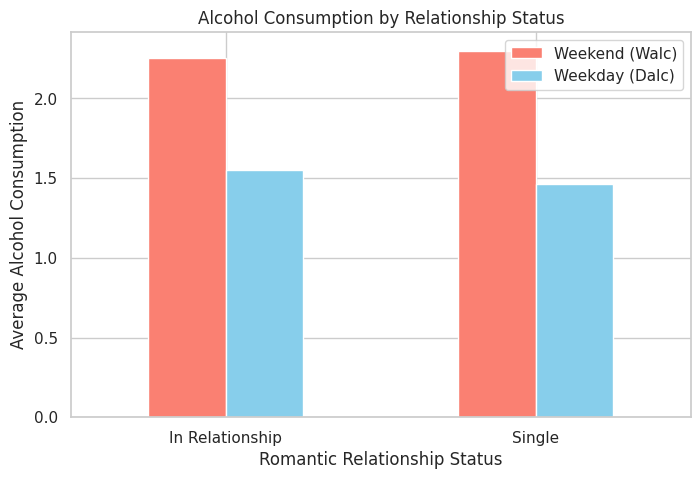

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load and combine the datasets
math_df = pd.read_csv('/content/student-mat.csv')
por_df = pd.read_csv('/content/student-por.csv')

math_df['course'] = 'Math'
por_df['course'] = 'Portuguese'

df = pd.concat([math_df, por_df], ignore_index=True)

# Map labels for clarity
df['romantic'] = df['romantic'].map({'yes': 'In Relationship', 'no': 'Single'})

# Set style
sns.set(style="whitegrid")

# Plot 1: Weekend alcohol consumption (Walc) vs Social Activity (goout)
plt.figure(figsize=(8,5))
sns.barplot(x='goout', y='Walc', data=df, palette='coolwarm')
plt.title('Weekend Alcohol Consumption vs Social Activity Level')
plt.xlabel('Social Activity Level (1=Low, 5=High)')
plt.ylabel('Average Weekend Alcohol Consumption (Walc)')
plt.show()

# Plot 2: Romantic relationship vs Average Alcohol Consumption (Walc & Dalc)
romantic_group = df.groupby('romantic')[['Walc', 'Dalc']].mean().reset_index()

romantic_group.plot(x='romantic', kind='bar', figsize=(8,5), color=['salmon', 'skyblue'])
plt.title('Alcohol Consumption by Relationship Status')
plt.xlabel('Romantic Relationship Status')
plt.ylabel('Average Alcohol Consumption')
plt.legend(['Weekend (Walc)', 'Weekday (Dalc)'])
plt.xticks(rotation=0)
plt.show()


# **Insight:**

Students who frequently go out with friends (goout levels 4–5) show significantly higher weekend alcohol consumption. This indicates that social activity is a strong driver of drinking behavior, likely due to peer influence and party culture.

Surprisingly, single students consume more alcohol than those in romantic relationships, on both weekdays (Dalc) and weekends (Walc).

# **Q7. Do study habits (studytime) and digital access (internet) play a protective role against high alcohol use?**

Optimization terminated successfully.
         Current function value: 0.457950
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           high_alcohol   No. Observations:                 1044
Model:                          Logit   Df Residuals:                     1041
Method:                           MLE   Df Model:                            2
Date:                Fri, 18 Apr 2025   Pseudo R-squ.:                 0.04616
Time:                        10:42:37   Log-Likelihood:                -478.10
converged:                       True   LL-Null:                       -501.24
Covariance Type:            nonrobust   LLR p-value:                 8.961e-11
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2743      0.261     -1.049      0.294      -0.787       0.238
studytime     -0.7302      0.

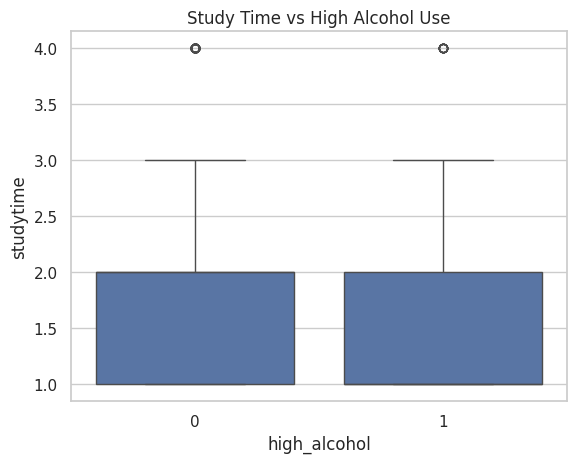

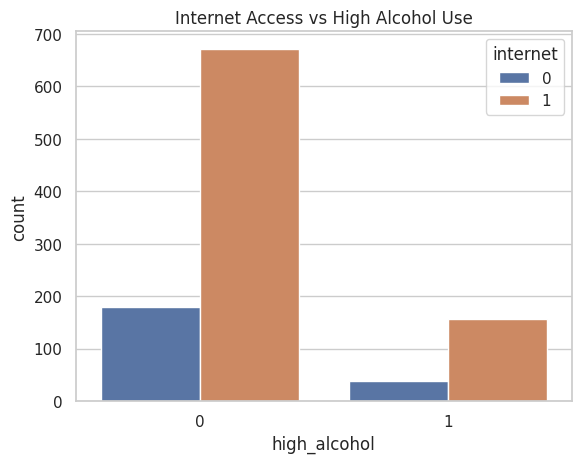

In [ ]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
# Replace with the actual path or DataFrame if you already have one
df1 = pd.read_csv("student-mat.csv")
df2 = pd.read_csv("student-por.csv")

#Concatenate both datasets
df = pd.concat([df1, df2], ignore_index=True)

# Create a binary variable for high alcohol use
# Assume 'Dalc' (weekday) and 'Walc' (weekend) are columns (0–5 scale)
df['high_alcohol'] = ((df['Dalc'] + df['Walc']) / 2 >= 3).astype(int)  # Threshold can be adjusted

# Convert categorical predictors if needed
df['internet'] = df['internet'].map({'yes': 1, 'no': 0})

# Define predictors and outcome
X = df[['studytime', 'internet']]
X = sm.add_constant(X)  # Adds intercept
y = df['high_alcohol']

# Fit logistic regression
model = sm.Logit(y, X).fit()

# Print summary
print(model.summary())

# visualize relationships
sns.boxplot(x='high_alcohol', y='studytime', data=df)
plt.title("Study Time vs High Alcohol Use")
plt.show()

sns.countplot(x='high_alcohol', hue='internet', data=df)
plt.title("Internet Access vs High Alcohol Use")
plt.show()

Insight 1: There’s no significant difference in average study time between students with high and low alcohol use. This suggests that study time alone may not strongly predict alcohol consumption.


Insight2: Most students, regardless of their alcohol consumption level, have internet access.

However, high alcohol use is slightly more common among students who have internet access — but this may be because the majority of all students have internet, so it's not a strong predictor by itself.

# **Q8. Are students taking paid classes (paid) more likely to consume alcohol — and could this point to greater financial freedom, not just academic seriousness?**

Optimization terminated successfully.
         Current function value: 0.479807
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:           high_alcohol   No. Observations:                 1044
Model:                          Logit   Df Residuals:                     1042
Method:                           MLE   Df Model:                            1
Date:                Fri, 18 Apr 2025   Pseudo R-squ.:               0.0006326
Time:                        10:42:40   Log-Likelihood:                -500.92
converged:                       True   LL-Null:                       -501.24
Covariance Type:            nonrobust   LLR p-value:                    0.4258
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5108      0.091    -16.691      0.000      -1.688      -1.333
paid           0.1526      0.

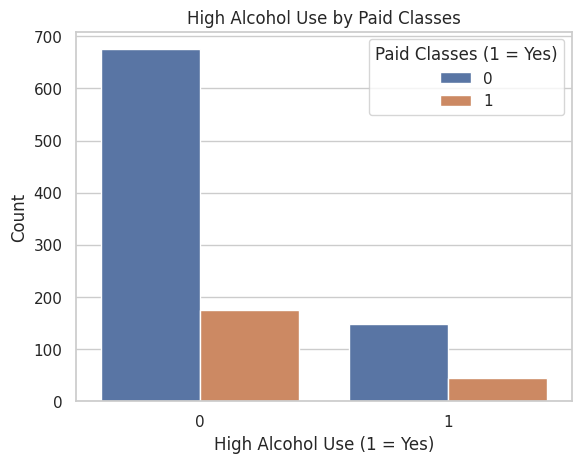

In [ ]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# Load your dataset
df1 = pd.read_csv("student-mat.csv")
df2 = pd.read_csv("student-por.csv")

#Concatenate both datasets
df = pd.concat([df1, df2], ignore_index=True)

# Reuse the high_alcohol definition
df['high_alcohol'] = ((df['Dalc'] + df['Walc']) / 2 >= 3).astype(int)

# Convert 'paid' column to binary: 'yes' → 1, 'no' → 0
df['paid'] = df['paid'].map({'yes': 1, 'no': 0})

# Define predictors and outcome
X = sm.add_constant(df[['paid']])
y = df['high_alcohol']

# Logistic regression
model = sm.Logit(y, X).fit()

# Show results
print(model.summary())

# visualize
sns.countplot(x='high_alcohol', hue='paid', data=df)
plt.title("High Alcohol Use by Paid Classes")
plt.xlabel("High Alcohol Use (1 = Yes)")
plt.ylabel("Count")
plt.legend(title="Paid Classes (1 = Yes)")
plt.show()

INSIGHT: From this visualization, it's clear that high alcohol use is more common among students who did not attend paid classes. Students who did attend paid classes tend to have lower alcohol use.

# **Q9. Among students who consume alcohol moderately or heavily, what traits help some still achieve high grades (G3)?**

,G3,alcohol_level,studytime,failures,goout,famsup,activities,higher,internet,absences
27,15,Moderate,1,0,4,no,no,yes,yes,4
69,16,Moderate,4,0,2,yes,no,yes,yes,12
129,18,Moderate,1,0,5,no,yes,yes,yes,8
182,17,Moderate,2,0,2,yes,yes,yes,no,0
198,18,Moderate,1,1,4,yes,no,yes,yes,24
200,16,Moderate,2,0,5,yes,yes,yes,yes,2
249,15,Moderate,1,0,2,no,no,yes,yes,0
265,17,Moderate,2,0,5,yes,yes,yes,yes,13
323,15,Moderate,3,0,3,yes,no,yes,yes,1
324,15,Moderate,3,0,3,no,no,yes,yes,0


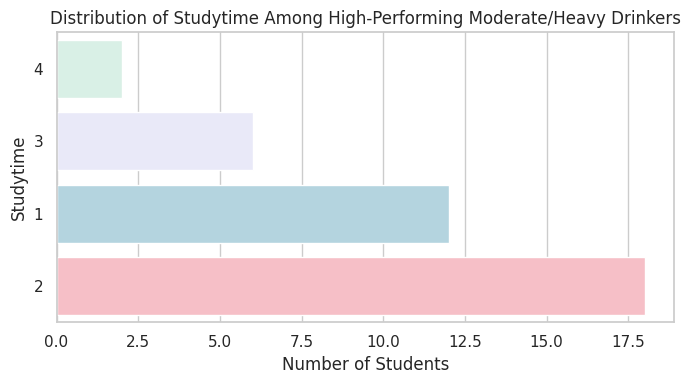

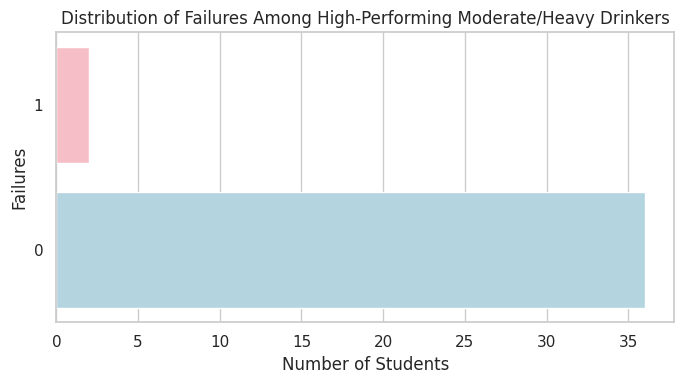

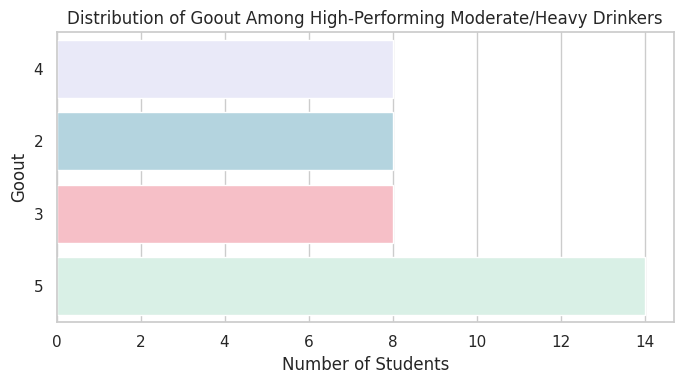

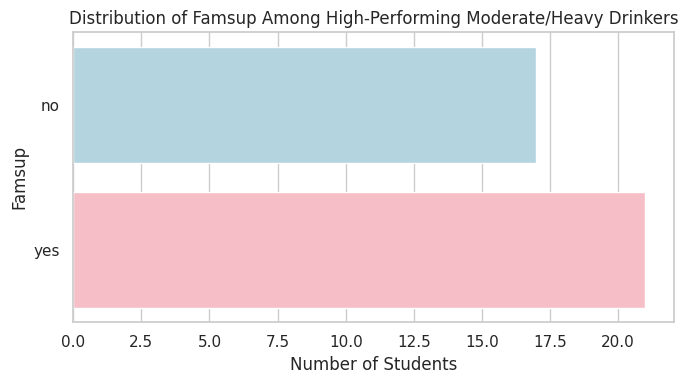

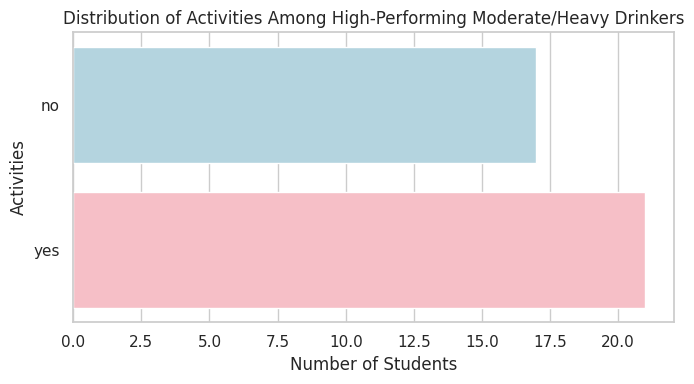

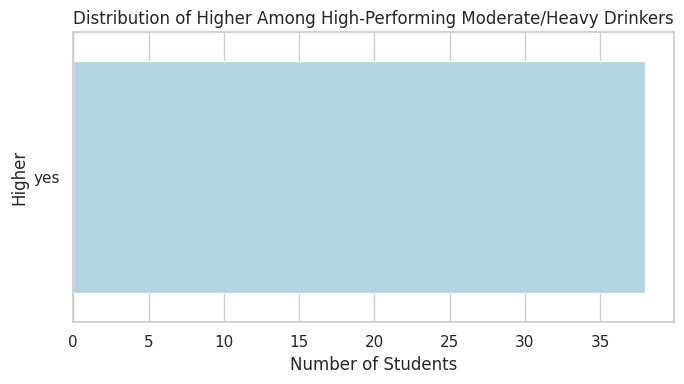

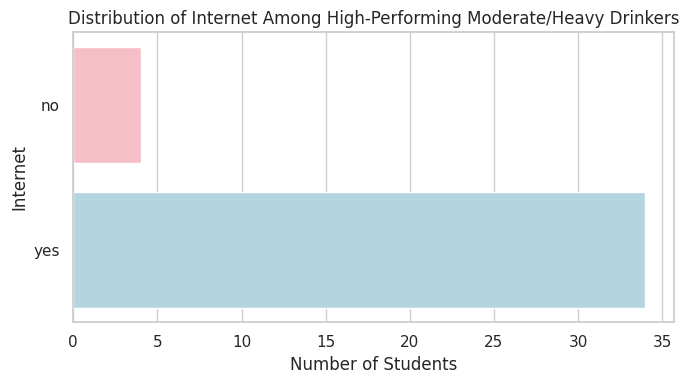

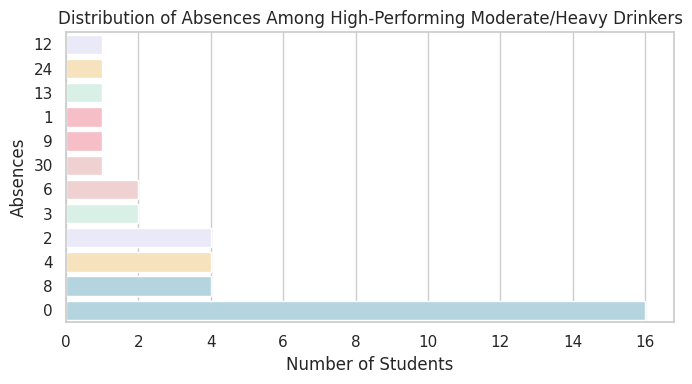

In [ ]:
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt


# Load both datasets
df1 = pd.read_csv("student-mat.csv")
df2 = pd.read_csv("student-por.csv")

# Concatenate both datasets
df = pd.concat([df1, df2], ignore_index=True)

# Create average alcohol consumption
df['avg_alcohol'] = (df['Dalc'] + df['Walc']) / 2

# Create category for alcohol level
df['alcohol_level'] = pd.cut(df['avg_alcohol'],
                             bins=[0, 2, 3.5, 5],
                             labels=['Low', 'Moderate', 'High'])

# Filter for moderate or high alcohol consumers
high_alcohol = df[df['alcohol_level'].isin(['Moderate', 'High'])]

# Filter students with G3 (final grade) >= 15
high_alcohol_high_grades = high_alcohol[high_alcohol['G3'] >= 15]

# Relevant traits including absences
traits = ['G3', 'alcohol_level', 'studytime', 'failures', 'goout',
          'famsup', 'activities', 'higher', 'internet', 'absences']

# Display the table
display_table = high_alcohol_high_grades[traits]
display(display_table)

# Set pastel aesthetic style
sns.set(style="whitegrid")

# Define a pastel color palette
custom_palette = ["#add8e6",  # Light Blue
                  "#ffb6c1",  # Light Pink
                  "#e6e6fa",  # Lavender
                  "#d5f4e6",  # Mint
                  "#ffe5b4",  # Peach
                  "#f4cccc"]  # Blush

# Plot graphs for selected traits
selected_traits = ['studytime', 'failures', 'goout', 'famsup',
                   'activities', 'higher', 'internet', 'absences']

for trait in selected_traits:
    plt.figure(figsize=(7, 4))
    order = high_alcohol_high_grades[trait].value_counts().sort_values(ascending=True).index
    palette_len = len(order)

    sns.countplot(
        data=high_alcohol_high_grades,
        y=trait,
        hue=trait,
        order=order,
        palette=custom_palette[:palette_len],
        legend=False
    )

    plt.title(f'Distribution of {trait.capitalize()} Among High-Performing Moderate/Heavy Drinkers')
    plt.xlabel('Number of Students')
    plt.ylabel(trait.capitalize())
    plt.tight_layout()
    plt.show()

##Insights
*   High-achieving students typically have higher study time (3–4 hours/week).
*   They have zero or very few past failures.
*   Moderate socializing is more common than excessive going out.
*   Family support (famsup) plays a key role.
*   Many are involved in extracurricular activities.
* Strong aspiration for higher education is a common trait.
*  Most have internet access, which may aid academics.
*  They have low absenteeism, showing consistency.

####High-performing alcohol-consuming students succeed due to a strong academic foundation — characterized by consistent study habits, minimal past failures, and clear long-term goals like pursuing higher education, supported by structured routines and family encouragement.

# **Q10. How do some students successfully balance social life and academics while still engaging in alcohol use?**


,internet,Dalc,Walc,higher,studytime,goout,absences,activities,G3
2,yes,2,3,yes,2,2,10,no,10
18,yes,2,4,yes,1,5,16,yes,5
23,yes,2,4,yes,2,4,0,yes,12
27,yes,2,4,yes,1,4,4,no,15
29,yes,5,5,yes,2,5,16,yes,11


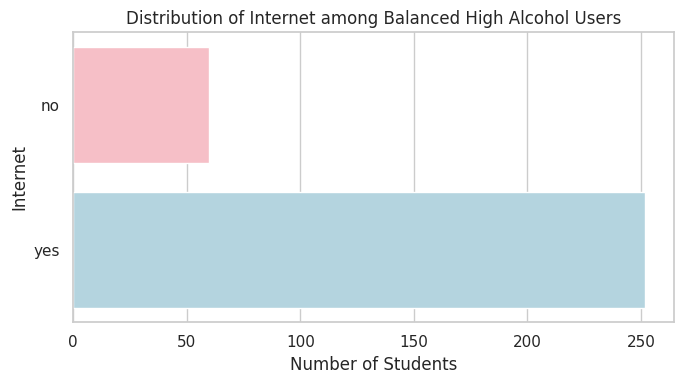

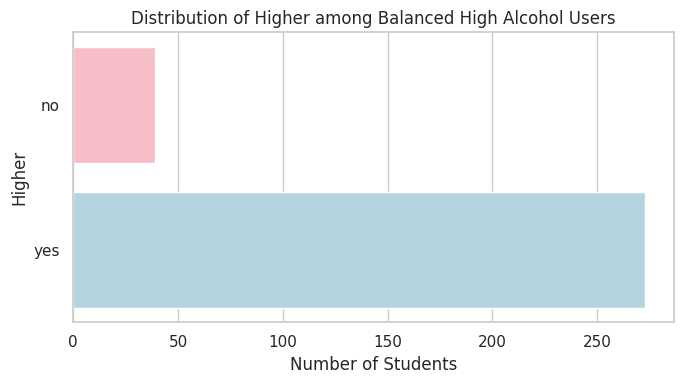

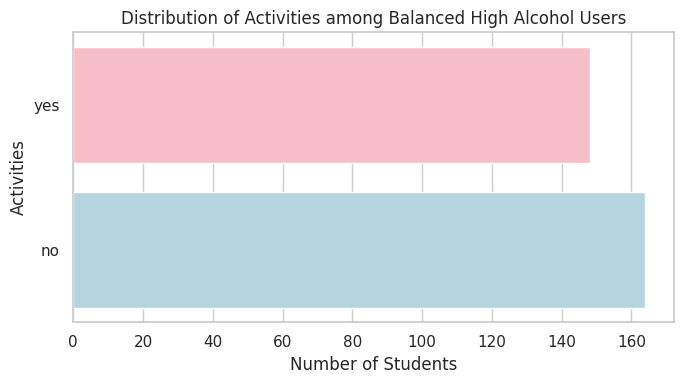

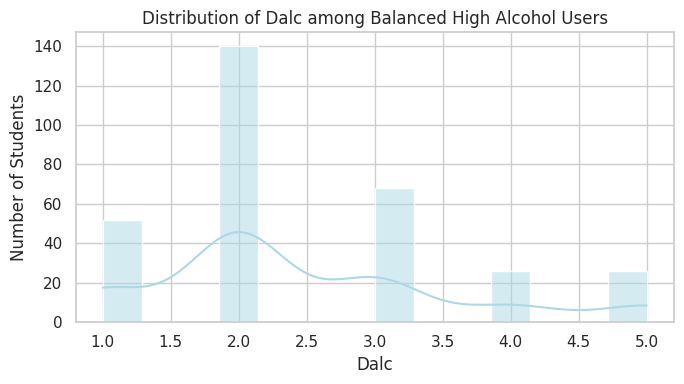

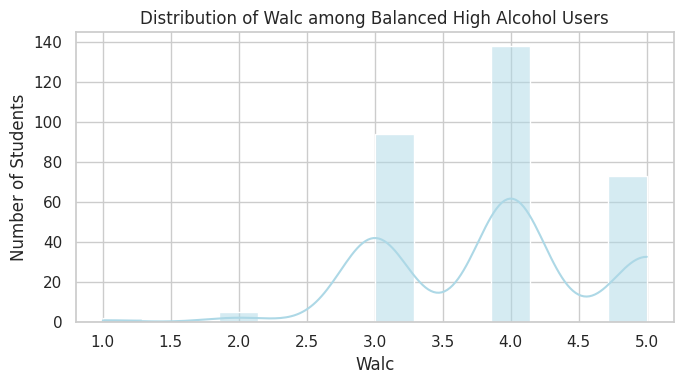

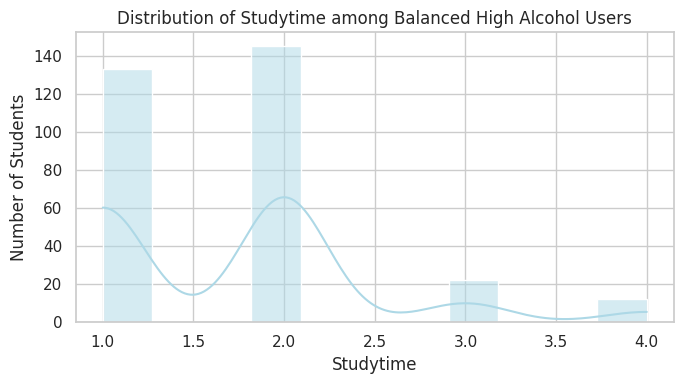

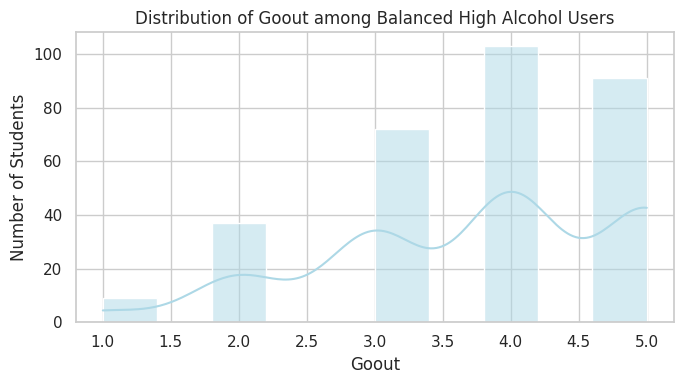

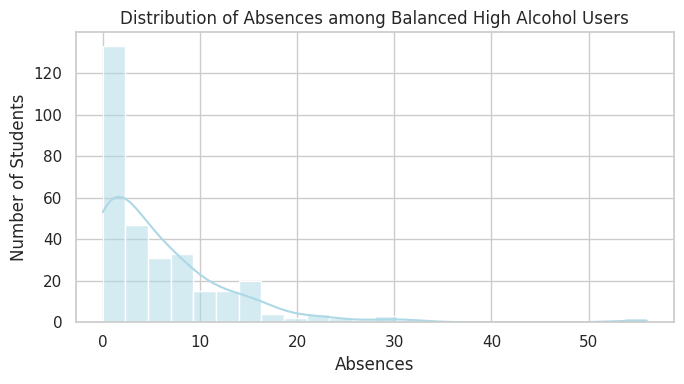

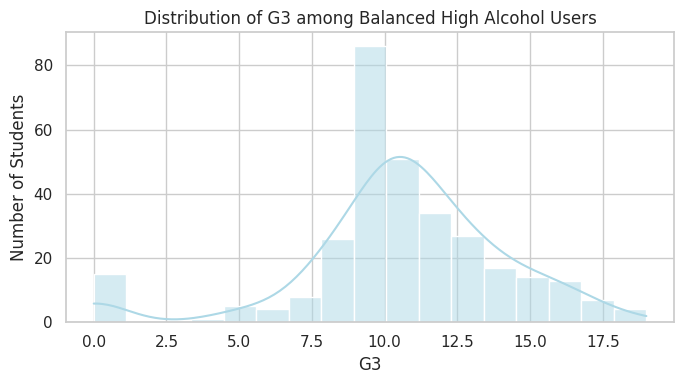

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load both datasets
df_mat = pd.read_csv("student-mat.csv")
df_por = pd.read_csv("student-por.csv")

# Combine datasets
df = pd.concat([df_mat, df_por], ignore_index=True)

# Create average alcohol consumption
df['avg_alcohol'] = (df['Dalc'] + df['Walc']) / 2

# Categorize alcohol consumption
df['alcohol_level'] = pd.cut(df['avg_alcohol'],
                             bins=[0, 2, 3.5, 5],
                             labels=['Low', 'Moderate', 'High'])

# Filter students with moderate or high alcohol consumption
high_alcohol = df[df['alcohol_level'].isin(['Moderate', 'High'])]

# Traits for balance between social life and academics
traits_q10 = ['internet', 'Dalc', 'Walc', 'higher', 'studytime', 'goout', 'absences', 'activities', 'G3']
q10_df = high_alcohol[traits_q10]

# Preview the dataset
display(q10_df.head())

# Set a pastel-style custom palette
custom_palette = ["#add8e6", "#ffb6c1", "#e6e6fa", "#d5f4e6", "#ffe5b4"]

# Function to plot categorical traits
def plot_categorical_traits(traits):
    for trait in traits:
        plt.figure(figsize=(7, 4))
        order = q10_df[trait].value_counts().sort_values(ascending=True).index
        sns.countplot(data=q10_df, y=trait, order=order, palette=custom_palette[:len(order)], hue=trait, legend=False)
        plt.title(f'Distribution of {trait.capitalize()} among Balanced High Alcohol Users')
        plt.xlabel('Number of Students')
        plt.ylabel(trait.capitalize())
        plt.tight_layout()
        plt.show()

# Function to plot numerical traits
def plot_numerical_traits(traits):
    for trait in traits:
        plt.figure(figsize=(7, 4))
        sns.histplot(q10_df[trait], kde=True, color="#add8e6")
        plt.title(f'Distribution of {trait.capitalize()} among Balanced High Alcohol Users')
        plt.xlabel(trait.capitalize())
        plt.ylabel('Number of Students')
        plt.tight_layout()
        plt.show()

# Plot categorical traits
categorical_traits = ['internet', 'higher', 'activities']
plot_categorical_traits(categorical_traits)

# Plot numerical traits
numerical_traits = ['Dalc', 'Walc', 'studytime', 'goout', 'absences', 'G3']
plot_numerical_traits(numerical_traits)





###Insights
*   Moderate study time (2–3 hours/week) supports balance.
*   Going out 2–3 times a week is typical — not too much, not too little.
*   Weekend alcohol use is more common than daily, indicating social drinking.
*   Active participation in extracurriculars reflects good time management.
*   Having a goal of pursuing higher education motivates balance.
*   Lower absences indicate better discipline and routine.
*   Internet access is common — potentially used for both academics and recreation.

####Students who balance social life and academics while drinking tend to do so by maintaining moderate habits — they limit daily alcohol use, stay engaged in structured extracurriculars, and combine socializing with a clear academic drive, showing that balance stems from controlled lifestyle choices rather than extremes.

----
#**Researchers**
----

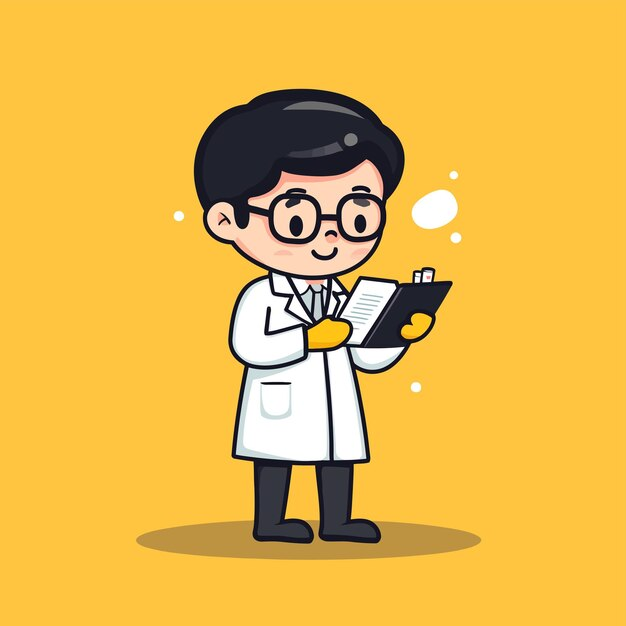

# **Q11. What are the top predictive features of high weekend alcohol use (Walc ≥ 4)?**

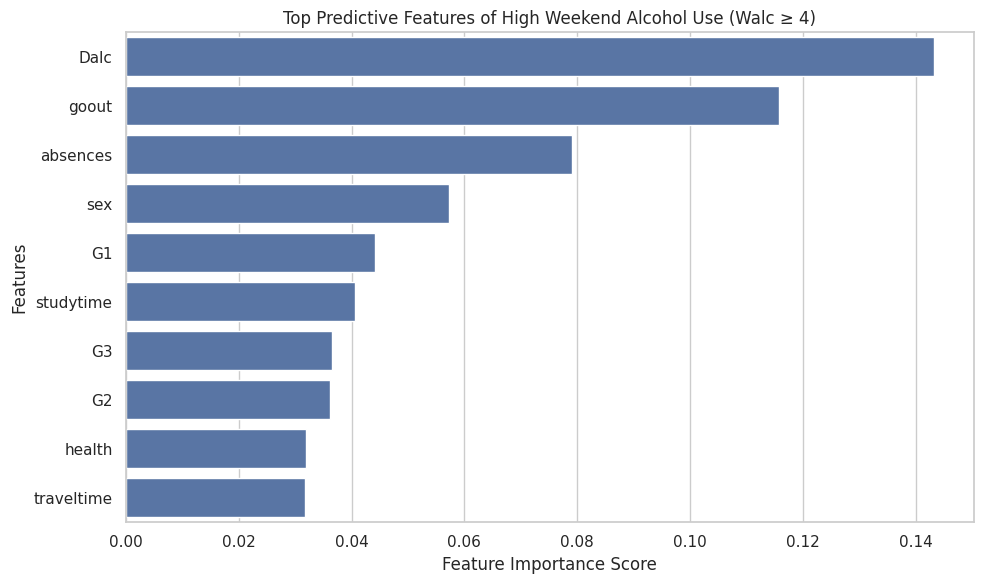

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load the data
df = pd.read_csv('student-mat.csv')  # or 'student-por.csv'

# Binary target variable: High weekend alcohol use
df['high_walc'] = df['Walc'].apply(lambda x: 1 if x >= 4 else 0)

# Encode categorical variables using LabelEncoder
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define features and target
X = df.drop(columns=['Walc', 'high_walc'])
y = df['high_walc']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Random Forest to find important predictors
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title('Top Predictive Features of High Weekend Alcohol Use (Walc ≥ 4)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


# **Q12. Can we develop a risk profile to identify students at high risk — those with high absences, high alcohol consumption, and low grades?**

In [ ]:
# Define conditions
high_absences = df['absences'] >= 10
high_alcohol = df['Walc'] >= 4
low_grades = df['G3'] <= 10

# Create a risk flag column
df['at_risk'] = (high_absences & high_alcohol & low_grades).astype(int)

# View at-risk student summary
print(df[df['at_risk'] == 1][['sex', 'age', 'absences', 'Walc', 'G3']].head())

# Optional: count of at-risk students
print("Number of at-risk students:", df['at_risk'].sum())


     sex  age  absences  Walc  G3
18     1   17        16     4   5
89     1   16        18     5   7
100    1   16        14     5   5
118    1   17        20     4   8
178    1   16        10     4   9
Number of at-risk students: 16
